# Student Outcomes Notebook (Fresh Build)


This notebook is a complete rework focused on understanding what drives placement and salary outcomes.


Workflow in this version:


1. Load and verify data quality


2. Engineer richer candidate signals


3. Explore relationships visually


4. Train and benchmark predictive models


5. Export reproducible artifacts

In [5]:
from __future__ import annotations

from pathlib import Path



import json

import warnings



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import seaborn as sns



from sklearn.compose import ColumnTransformer

from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingRegressor

from sklearn.linear_model import LogisticRegression, Ridge

from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, r2_score

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler



warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='notebook')

np.random.seed(42)

## 1) Data Ingestion and Schema Audit


Read source files and run a compact structural audit before doing any modeling.

In [6]:
features_path = Path('A.csv')

targets_path = Path('A_targets.csv')



if not features_path.exists() or not targets_path.exists():

    raise FileNotFoundError('Expected A.csv and A_targets.csv in the working directory.')



feature_df = pd.read_csv(features_path)

target_df = pd.read_csv(targets_path)

df = feature_df.merge(target_df, on='Student_ID', how='inner')



print(f'Rows: {df.shape[0]:,}')

print(f'Columns: {df.shape[1]}')

display(df.head(3))



schema = pd.DataFrame({

    'column': df.columns,

    'dtype': df.dtypes.astype(str),

    'missing': df.isna().sum().values,

    'missing_rate': (df.isna().mean().values * 100).round(2)

})

display(schema.sort_values(['missing_rate', 'column'], ascending=[False, True]))

Rows: 5,000
Columns: 25


,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73


,column,dtype,missing,missing_rate
extracurricular_involvement,extracurricular_involvement,object,1006,20.12
Student_ID,Student_ID,int64,0,0.00
aptitude_skill_rating,aptitude_skill_rating,int64,0,0.00
attendance_percentage,attendance_percentage,float64,0,0.00
backlogs,backlogs,int64,0,0.00
branch,branch,object,0,0.00
certifications_count,certifications_count,int64,0,0.00
cgpa,cgpa,float64,0,0.00
city_tier,city_tier,object,0,0.00
coding_skill_rating,coding_skill_rating,int64,0,0.00


## 2) Controlled Cleanup


Normalize categories, coerce numerics, and remove records that are unusable for downstream tasks.

In [7]:
raw = df.copy()



categorical_defaults = {

    'gender': 'Male',

    'part_time_job': 'No',

    'internet_access': 'Yes',

    'branch': 'CSE',

    'city_tier': 'Tier 2',

    'family_income_level': 'Medium',

    'extracurricular_involvement': 'Medium'

}



for col, default_val in categorical_defaults.items():

    if col in raw.columns:

        raw[col] = raw[col].fillna(default_val).astype(str).str.strip()



numeric_cols = [c for c in raw.columns if c not in categorical_defaults and c not in ['placement_status']]

for col in numeric_cols:

    raw[col] = pd.to_numeric(raw[col], errors='coerce')



clean = raw.dropna(subset=['salary_lpa']).copy()

clean['salary_lpa'] = clean['salary_lpa'].clip(lower=0)

clean['placement_flag'] = (clean['placement_status'].str.lower() == 'placed').astype(int)



print(f'Before cleanup: {len(df):,} rows')

print(f'After cleanup : {len(clean):,} rows')

display(clean.head(2))

Before cleanup: 5,000 rows
After cleanup : 5,000 rows


,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa,placement_flag
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95,1
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91,1


,min,median,max,std
Student_ID,1.0,2500.50,5000.0,1443.520
cgpa,5.0,8.32,10.0,1.008
tenth_percentage,50.0,74.70,100.0,10.267
twelfth_percentage,50.0,74.80,100.0,10.244
backlogs,0.0,0.00,5.0,0.613
study_hours_per_day,0.0,4.00,10.0,1.968
attendance_percentage,44.7,72.05,99.2,7.720
projects_completed,0.0,6.00,8.0,2.054
internships_completed,0.0,2.00,4.0,1.144
coding_skill_rating,1.0,4.00,5.0,1.278


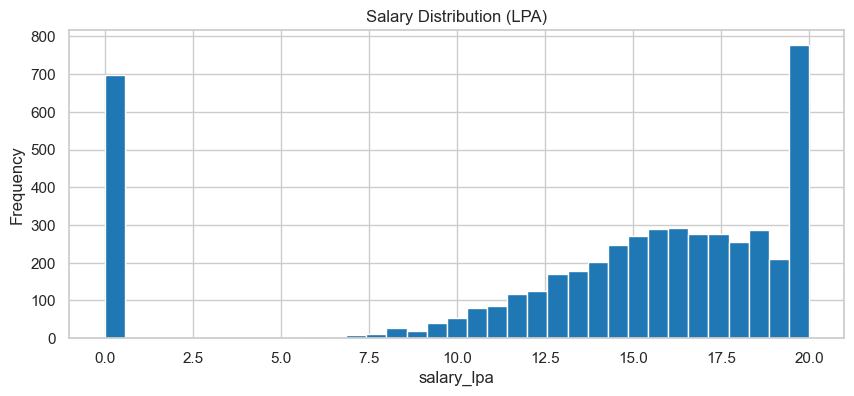

In [8]:
quality_snapshot = pd.DataFrame({

    'min': clean.min(numeric_only=True),

    'median': clean.median(numeric_only=True),

    'max': clean.max(numeric_only=True),

    'std': clean.std(numeric_only=True)

}).round(3)



display(quality_snapshot.head(12))



fig, ax = plt.subplots(figsize=(10, 4))

clean['salary_lpa'].plot(kind='hist', bins=35, color='#1f77b4', edgecolor='white', ax=ax)

ax.set_title('Salary Distribution (LPA)')

ax.set_xlabel('salary_lpa')

plt.show()

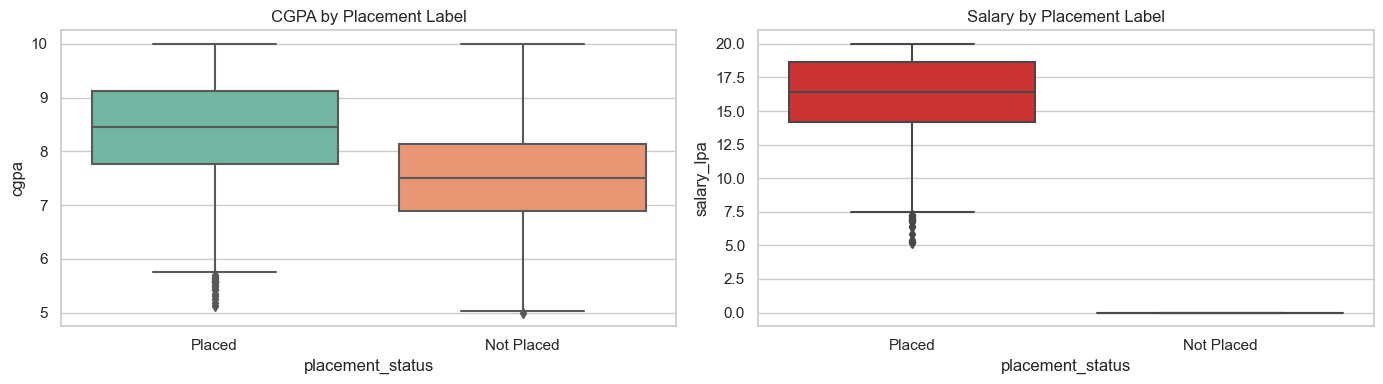

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))



sns.boxplot(data=clean, x='placement_status', y='cgpa', palette='Set2', ax=axes[0])

axes[0].set_title('CGPA by Placement Label')



sns.boxplot(data=clean, x='placement_status', y='salary_lpa', palette='Set1', ax=axes[1])

axes[1].set_title('Salary by Placement Label')



plt.tight_layout()

plt.show()

## 3) Feature Synthesis


Craft additional signals aimed at employability intensity, consistency, and readiness.

In [10]:
feat = clean.copy()



feat['skill_stack'] = feat[['coding_skill_rating', 'communication_skill_rating', 'aptitude_skill_rating']].mean(axis=1)

feat['project_depth'] = (feat['projects_completed'] + 1.5 * feat['internships_completed'] + 0.75 * feat['certifications_count'])

feat['academic_track'] = (feat['cgpa'] * 10 + feat['tenth_percentage'] + feat['twelfth_percentage']) / 3

feat['stability_ratio'] = (feat['sleep_hours'].clip(lower=1)) / (feat['stress_level'].clip(lower=1))

feat['engagement_signal'] = feat['study_hours_per_day'] + (feat['attendance_percentage'] / 20)

feat['career_drive'] = feat['project_depth'] + feat['hackathons_participated']



engineered_cols = ['skill_stack', 'project_depth', 'academic_track', 'stability_ratio', 'engagement_signal', 'career_drive']

display(feat[engineered_cols].describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
skill_stack,5000.0,3.623,0.698,1.333,3.000,3.667,4.000,5.000
project_depth,5000.0,10.855,3.416,0.000,8.500,11.000,13.250,20.750
academic_track,5000.0,77.306,9.635,50.067,70.758,77.567,84.400,98.567
stability_ratio,5000.0,1.781,1.700,0.400,0.812,1.140,1.933,9.000
engagement_signal,5000.0,7.643,2.276,2.545,6.060,7.592,9.195,14.905
career_drive,5000.0,14.560,4.539,0.750,11.250,15.000,18.000,26.000


## 4) Correlation and Segment Views


Inspect how engineered signals move with the two targets and inspect segment-level behavior.

,placement_flag,salary_lpa
placement_flag,1.000,0.895
salary_lpa,0.895,1.000
career_drive,0.377,0.592
project_depth,0.371,0.581
coding_skill_rating,0.343,0.497
skill_stack,0.333,0.502
projects_completed,0.323,0.457
cgpa,0.316,0.550
academic_track,0.301,0.530
hackathons_participated,0.276,0.439


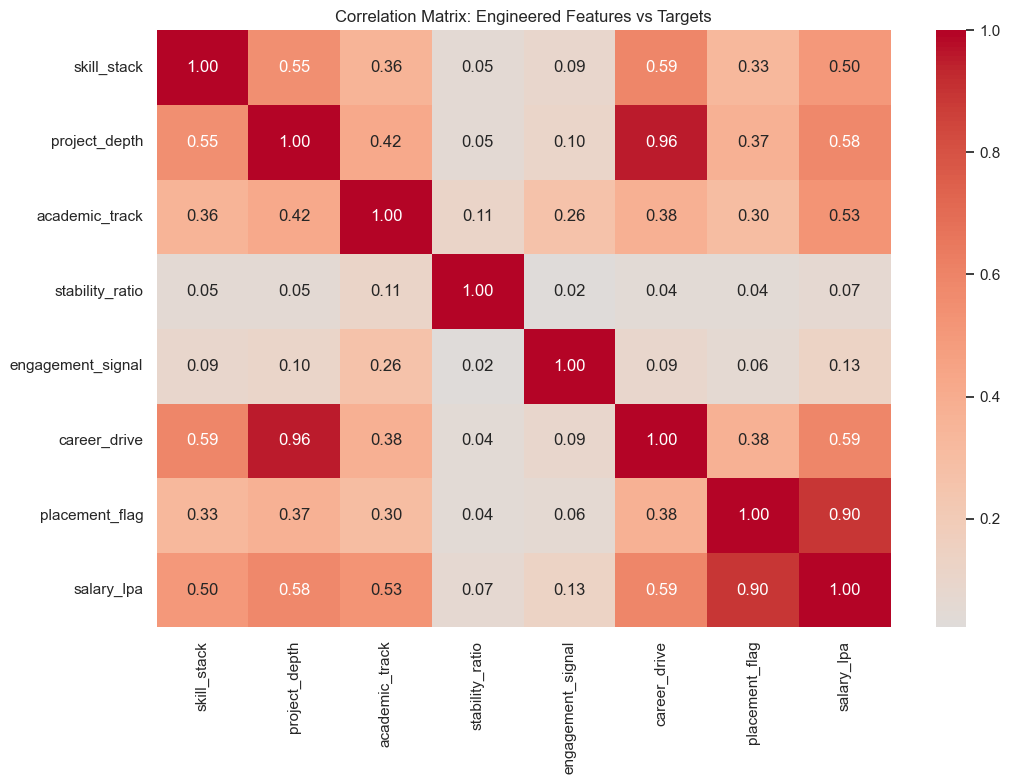

In [11]:
num = feat.select_dtypes(include=[np.number]).copy()

corr = num.corr(numeric_only=True)



target_corr = corr[['placement_flag', 'salary_lpa']].sort_values('placement_flag', ascending=False)

display(target_corr.head(15).round(3))



plt.figure(figsize=(11, 8))

sns.heatmap(corr.loc[engineered_cols + ['placement_flag', 'salary_lpa'], engineered_cols + ['placement_flag', 'salary_lpa']], annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Correlation Matrix: Engineered Features vs Targets')

plt.tight_layout()

plt.show()

## 5) Build Model Matrices


Use robust preprocessing with one-hot encoding and split data for both tasks.

In [12]:
target_clf = 'placement_flag'

target_reg = 'salary_lpa'



drop_cols = ['placement_status', 'Student_ID']

base_X = feat.drop(columns=drop_cols)



cat_cols = base_X.select_dtypes(include=['object']).columns.tolist()

num_cols = [c for c in base_X.columns if c not in cat_cols and c not in [target_clf, target_reg]]



X = base_X.drop(columns=[target_clf, target_reg])

y_clf = feat[target_clf]

y_reg = feat[target_reg]



X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(

    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf

)



X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(

    X, y_reg, test_size=0.2, random_state=42

)



pre = ColumnTransformer(

    transformers=[

        ('num', StandardScaler(), num_cols),

        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),

    ]

)



print('Train/Test (classification):', X_train_c.shape, X_test_c.shape)

print('Train/Test (regression):', X_train_r.shape, X_test_r.shape)

Train/Test (classification): (4000, 28) (1000, 28)
Train/Test (regression): (4000, 28) (1000, 28)


## 6) Placement Model Tournament


Compare a linear baseline and a tree ensemble using weighted $F_1$ and accuracy.

In [13]:
clf_candidates = {

    'logistic': LogisticRegression(max_iter=1500, random_state=42),

    'extra_trees': ExtraTreesClassifier(n_estimators=250, random_state=42)

}



clf_rows = []

best_clf_name = None

best_clf_score = -1

best_clf_pipe = None



for name, model in clf_candidates.items():

    pipe = Pipeline([('pre', pre), ('model', model)])

    pipe.fit(X_train_c, y_train_c)

    pred = pipe.predict(X_test_c)



    f1w = f1_score(y_test_c, pred, average='weighted')

    acc = accuracy_score(y_test_c, pred)

    clf_rows.append({'model': name, 'f1_weighted': f1w, 'accuracy': acc})



    if f1w > best_clf_score:

        best_clf_score = f1w

        best_clf_name = name

        best_clf_pipe = pipe



clf_results = pd.DataFrame(clf_rows).sort_values('f1_weighted', ascending=False)

display(clf_results.round(4))

print(f'Best placement model: {best_clf_name}')

,model,f1_weighted,accuracy
0,logistic,0.8824,0.891
1,extra_trees,0.8662,0.885


Best placement model: logistic


## 7) Salary Model Tournament


Compare linear and boosted approaches and track $R^2$ and MAE for holdout performance.

In [14]:
reg_candidates = {

    'ridge': Ridge(alpha=1.0),

    'hist_gbr': HistGradientBoostingRegressor(random_state=42)

}



reg_rows = []

best_reg_name = None

best_reg_score = -1e9

best_reg_pipe = None



for name, model in reg_candidates.items():

    pipe = Pipeline([('pre', pre), ('model', model)])

    pipe.fit(X_train_r, y_train_r)

    pred = pipe.predict(X_test_r)



    r2 = r2_score(y_test_r, pred)

    mae = mean_absolute_error(y_test_r, pred)

    reg_rows.append({'model': name, 'r2': r2, 'mae': mae})



    if r2 > best_reg_score:

        best_reg_score = r2

        best_reg_name = name

        best_reg_pipe = pipe



reg_results = pd.DataFrame(reg_rows).sort_values('r2', ascending=False)

display(reg_results.round(4))

print(f'Best salary model: {best_reg_name}')

,model,r2,mae
0,ridge,0.5973,2.8501
1,hist_gbr,0.5806,2.6767


Best salary model: ridge


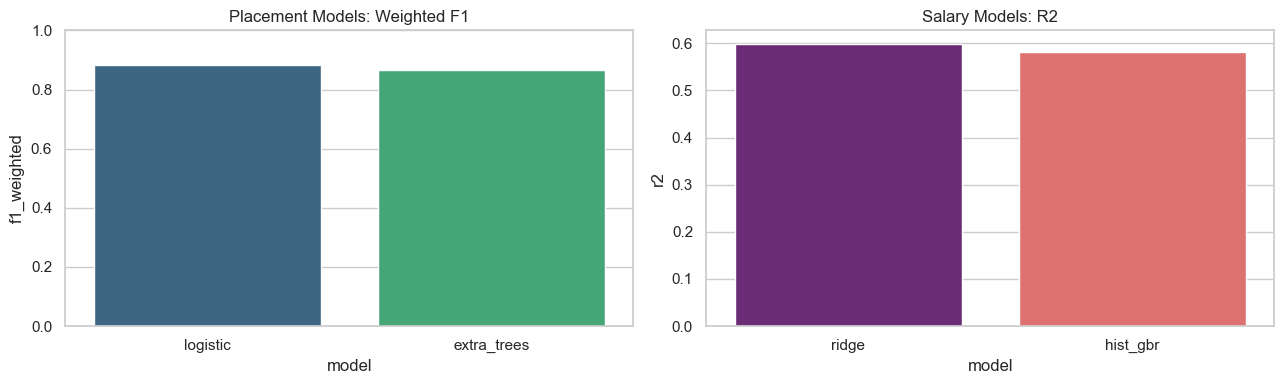

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))



sns.barplot(data=clf_results, x='model', y='f1_weighted', palette='viridis', ax=axes[0])

axes[0].set_title('Placement Models: Weighted F1')

axes[0].set_ylim(0, 1)



sns.barplot(data=reg_results, x='model', y='r2', palette='magma', ax=axes[1])

axes[1].set_title('Salary Models: R2')



plt.tight_layout()

plt.show()

## 8) Error Diagnostics and Fairness Snapshots


Review where each model struggles and inspect aggregate outcomes by selected cohorts.

In [16]:
clf_pred = best_clf_pipe.predict(X_test_c)

reg_pred = best_reg_pipe.predict(X_test_r)



clf_eval = X_test_c.copy()

clf_eval['actual'] = y_test_c.values

clf_eval['pred'] = clf_pred

clf_eval['miss'] = (clf_eval['actual'] != clf_eval['pred']).astype(int)



segment_error = (

    clf_eval.groupby('branch', dropna=False)['miss']

    .mean()

    .sort_values(ascending=False)

    .rename('placement_error_rate')

)

display(segment_error.to_frame().round(3))



reg_eval = pd.DataFrame({

    'actual_salary': y_test_r.values,

    'pred_salary': reg_pred

})

reg_eval['abs_err'] = (reg_eval['actual_salary'] - reg_eval['pred_salary']).abs()



print('Top salary misses:')

display(reg_eval.sort_values('abs_err', ascending=False).head(10).round(3))

,placement_error_rate
branch,
ME,0.181
CE,0.140
ECE,0.125
IT,0.077
CSE,0.069


Top salary misses:


,actual_salary,pred_salary,abs_err
823,0.0,16.357,16.357
605,0.0,13.842,13.842
566,0.0,13.597,13.597
701,0.0,13.527,13.527
110,0.0,13.444,13.444
649,0.0,13.230,13.230
120,0.0,13.118,13.118
178,16.6,3.608,12.992
834,0.0,12.856,12.856
398,0.0,12.714,12.714


,gender,city_tier,placement_rate,mean_salary,mean_skill,n
4,Male,Tier 2,0.870,14.014,3.631,1189
0,Female,Tier 1,0.869,13.997,3.643,535
2,Female,Tier 3,0.861,13.926,3.639,632
5,Male,Tier 3,0.856,13.972,3.632,915
1,Female,Tier 2,0.854,13.723,3.576,834
3,Male,Tier 1,0.854,13.747,3.626,895


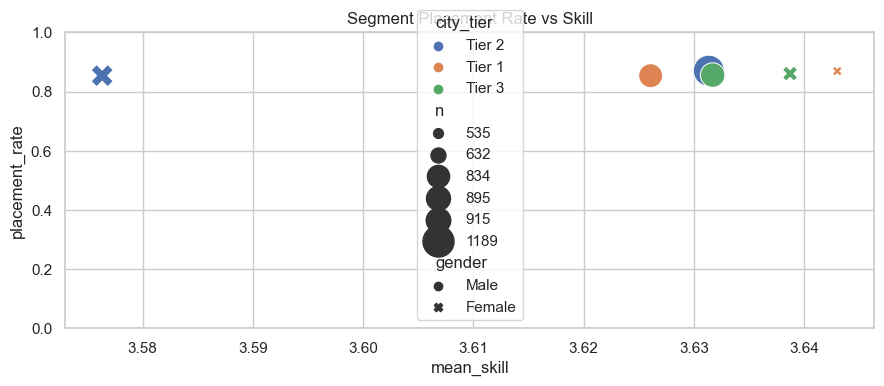

In [17]:
summary_table = (

    feat.groupby(['gender', 'city_tier'])

    .agg(

        placement_rate=('placement_flag', 'mean'),

        mean_salary=('salary_lpa', 'mean'),

        mean_skill=('skill_stack', 'mean'),

        n=('Student_ID', 'count')

    )

    .reset_index()

    .sort_values('placement_rate', ascending=False)

)

display(summary_table.round(3))



plt.figure(figsize=(9, 4))

sns.scatterplot(

    data=summary_table,

    x='mean_skill',

    y='placement_rate',

    size='n',

    hue='city_tier',

    style='gender',

    sizes=(50, 500)

)

plt.title('Segment Placement Rate vs Skill')

plt.ylim(0, 1)

plt.tight_layout()

plt.show()

## 9) Export Artifacts for Deployment


Persist compact model packages and metadata so downstream apps can load them quickly.


Saved outputs:


- best_placement_model.pkl


- best_salary_model.pkl


- notebook_training_metadata.json

In [18]:
output_dir = Path('saved_models')

output_dir.mkdir(parents=True, exist_ok=True)



import joblib



joblib.dump(best_clf_pipe, output_dir / 'best_placement_model.pkl')

joblib.dump(best_reg_pipe, output_dir / 'best_salary_model.pkl')



metadata = {

    'best_classification_model': best_clf_name,

    'best_regression_model': best_reg_name,

    'classification_results': clf_results.to_dict(orient='records'),

    'regression_results': reg_results.to_dict(orient='records'),

    'feature_columns': X.columns.tolist(),

    'generated_at': pd.Timestamp.utcnow().isoformat()

}



with open(output_dir / 'notebook_training_metadata.json', 'w', encoding='utf-8') as f:

    json.dump(metadata, f, indent=2)



print('Notebook artifacts saved to saved_models/')

print(' - best_placement_model.pkl')

print(' - best_salary_model.pkl')

print(' - notebook_training_metadata.json')

Notebook artifacts saved to saved_models/
 - best_placement_model.pkl
 - best_salary_model.pkl
 - notebook_training_metadata.json
